## Types of Loss Functions
- For Regression:
  - Mean Squared Error (MSE)
  - Mean Absolute Error (MAE)
  - Huber Loss
- For Classification:
  - Cross-Entropy Loss(Binary and Categorical)
  - Hinge Loss
  - Kullback-Leibler Divergence
- For Autoencoders:
  - Kullback-Leibler Divergence
- For Generative Adversarial Networks (GANs):
  - Adversarial Loss
  - Discriminator Loss
  - Minimax Loss

#### Mean Squared Error (MSE)
MSE is a common loss function used for regression tasks. It calculates the average of the squares of the differences between the predicted and actual values. The formula for MSE is:
```math
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
```
Where:
- $n$ is the number of samples
- $y_i$ is the actual value
- $\hat{y}_i$ is the predicted value

Advantages:
- MSE is easy to compute and differentiable, making it suitable for optimization algorithms like gradient descent.
- Easily interpretable as it represents the average squared error between predictions and actual values.
- It penalizes larger errors more than smaller ones, which can be beneficial in certain contexts.
- Only one local minimum, making it easier to optimize.

Disadvantages:
- MSE is sensitive to outliers, as it squares the errors, which can lead to disproportionately large loss values for outliers.
- As it squares the errors, it can be more difficult to interpret the magnitude of the error compared to other loss functions like MAE.
- For non-linear models, MSE can lead to slow convergence and may require careful tuning of learning rates and other hyperparameters.

#### Mean Absolute Error (MAE)
MAE is another loss function used for regression tasks. It calculates the average of the absolute differences between the predicted and actual values. The formula for MAE is:
```math
MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
```
Where:
- $n$ is the number of samples
- $y_i$ is the actual value
- $\hat{y}_i$ is the predicted value

Advantages:
- MAE is less sensitive to outliers compared to MSE, as it does not square the errors.
- It is easier to interpret as it represents the average absolute error between predictions and actual values.
- Same units as the target variable, making it more intuitive to understand the magnitude of errors.
- It can be more robust for certain types of data, especially when the data contains outliers or when the distribution of errors is not normal.
- It can be more suitable for certain types of regression problems where the magnitude of errors is more important than their squared values.

Disadvantages:
- MAE is not differentiable at zero, which can make it more difficult to optimize using gradient-based methods.
- It may not penalize larger errors as much as MSE, which can lead to suboptimal performance in certain contexts where larger errors are more detrimental.
- Computationally more expensive than MSE, as it requires calculating the absolute value of the errors, which can be more complex than squaring the errors in MSE.

#### Huber Loss
Huber Loss is a loss function that combines the advantages of both MSE and MAE to leverage their strengths while mitigating their weaknesses. It is defined as:
```math
L_{\delta}(y, \hat{y}) =
\begin{cases}
\frac{1}{2}(y - \hat{y})^2 & \text{for } |y - \hat{y}| \leq \delta \\
\delta(|y - \hat{y}| - \frac{1}{2}\delta) & \text{for } |y - \hat{y}| > \delta
\end{cases}
```
Where:
- $y$ is the actual value
- $\hat{y}$ is the predicted value
- $\delta$ is a hyperparameter that determines the threshold at which the loss function transitions from quadratic to linear

Advantages:
- Huber Loss is less sensitive to outliers than MSE, as it transitions to a linear loss for large errors, which can help prevent the model from being overly influenced by outliers.
- It is differentiable everywhere, making it easier to optimize using gradient-based methods.
- It provides a balance between the robustness of MAE and the smoothness of MSE, making it a good choice for many regression problems.

Disadvantages:
- The choice of the hyperparameter $\delta$ can be crucial and may require tuning to achieve optimal performance, which can add complexity to the model training process.
- It may not perform well in situations where the distribution of errors is heavily skewed or when the data contains a large number of outliers, as it may not fully capture the underlying patterns in the data.
- It can be computationalally more expensive than MSE, as it requires checking the condition for each error and calculating both the quadratic and linear components of the loss, which can increase the computational overhead during training.

#### Categorical Cross-Entropy Loss in Multi-Class Classification
Categorical Cross-Entropy Loss is a commonly used loss function for multi-class classification problems. It measures the difference between the predicted probability distribution and the true distribution (which is typically represented as a one-hot encoded vector). The formula for Categorical Cross-Entropy Loss is:
```math
L = -\sum_{i=1}^{n} y_i \log(\hat{y}_i)
```
Where:
- $n$ is the number of classes
- $y_i$ is the true label (1 for the correct class and 0 for the incorrect classes)
- $\hat{y}_i$ is the predicted probability for class $i$

Advantages:
- Categorical Cross-Entropy Loss is effective for multi-class classification tasks, as it directly measures the distance between the predicted probabilities and the true labels.
- Works naturally with probability outputs from models, making it suitable for classification tasks.
- It provides a clear and interpretable measure of the model's performance in terms of the likelihood of the correct class being predicted.

Disadvantages:
- Categorical Cross-Entropy Loss can be sensitive to class imbalance, as it may give more weight to the majority class, leading to suboptimal performance on minority classes.
- For mislabeled data, it can lead to very high loss values, which can negatively impact the training process and may require additional techniques such as label smoothing or class weighting to mitigate this issue.
- It can be computationalationally expensive for large numbers of classes, as it requires calculating the loss for each class, which can increase the computational overhead during training.
- It may not perform well in situations where the classes are not mutually exclusive or when the data contains a large number of classes, as it may not fully capturethe underlying patterns in the data.

### Vanishing Gradient Problem
The vanishing gradient problem is a common issue in training deep neural networks, where the gradients of the loss function with respect to the model parameters become very small as they are propagated back through the layers of the network. This can lead to slow convergence or even prevent the model from learning effectively, especially in deeper networks. Using sigmoid or tanh activation functions can exacerbate this problem, as they can cause the gradients to shrink exponentially as they are propagated back through the layers. To mitigate the vanishing gradient problem, techniques such as using ReLU activation functions, batch normalization, and residual connections can be employed. Reducing the model's depth or using architectures like LSTM or GRU for recurrent neural networks can also help address this issue.

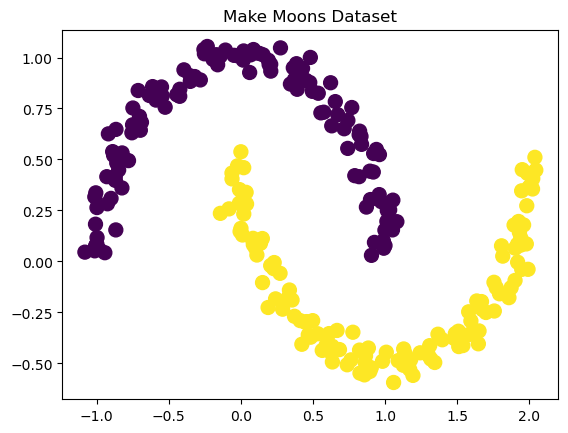

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

torch.manual_seed(42)

X, y = make_moons(n_samples=250, noise=0.05, random_state=42)

plt.scatter(X[:,0], X[:,1], c=y, s=100)
plt.title("Make Moons Dataset")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [3]:
class SigmoidNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,10), nn.Sigmoid(),
            nn.Linear(10,1), nn.Sigmoid(),
        )

    def forward(self,x):
        return self.net(x)


model = SigmoidNet()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

old_weights = model.net[0].weight.data.clone().numpy()
initial_weights = model.net[0].weight.data.clone()
weight_changes = []

epochs = 100

for epoch in range(epochs):

    optimizer.zero_grad()

    y_pred = model(X_train)

    loss = criterion(y_pred, y_train)

    loss.backward()

    optimizer.step()

    current_weights = model.net[0].weight.data.clone()

    change = torch.mean(torch.abs(current_weights - initial_weights)).item()

    weight_changes.append(change)

    if epoch % 10 == 0:
        print(f"Epoch {epoch} Loss: {loss.item():.4f}")

new_weights = model.net[0].weight.data.clone().numpy()
learning_rate = 0.001

gradient = (old_weights - new_weights) / learning_rate

percent_change = np.abs(100 * (old_weights - new_weights) / old_weights)

print("\nGradient:\n", gradient)

print("\nPercent Change:\n", percent_change)

Epoch 0 Loss: 0.6968
Epoch 10 Loss: 0.6942
Epoch 20 Loss: 0.6931
Epoch 30 Loss: 0.6930
Epoch 40 Loss: 0.6930
Epoch 50 Loss: 0.6930
Epoch 60 Loss: 0.6929
Epoch 70 Loss: 0.6929
Epoch 80 Loss: 0.6929
Epoch 90 Loss: 0.6929

Gradient:
 [[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]

Percent Change:
 [[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]


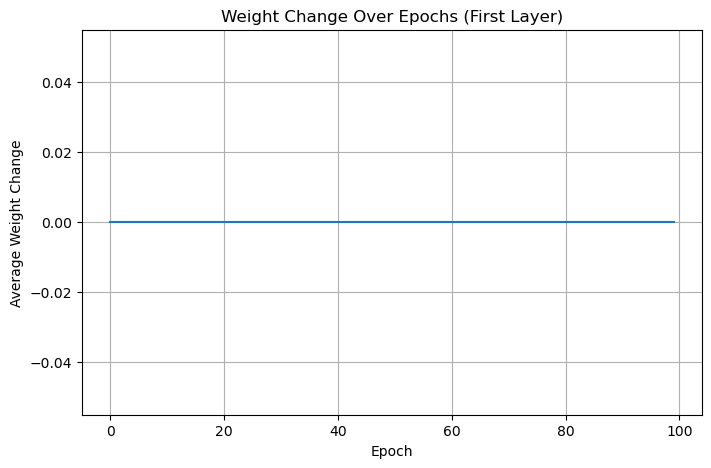

In [4]:
plt.figure(figsize=(8,5))
plt.plot(weight_changes)

plt.xlabel("Epoch")
plt.ylabel("Average Weight Change")
plt.title("Weight Change Over Epochs (First Layer)")
plt.grid(True)

plt.show()